<img src="p2_20_forceed.jpg" style="width: 400px;"/>

In [2]:
from numpy import sqrt, rad2deg, angle, linspace, exp
from matplotlib.pyplot import (figure, plot, xlabel, ylabel, grid,
                legend, show)

In [3]:
m = 1750
c = 3500
k = 7.0e5
a = 1.25
b = 2.5

In [4]:
ω_n = sqrt(k*a*a/m/b/b)
ζ   = c/m/2/ω_n
ω_d = sqrt(1 - ζ*ζ)*ω_n
print('ζ = {:.4f}'.format(ζ))
print('ω_n = {:.4f} rad/s'.format(ω_n))
print('ω_d = {:.4f} rad/s'.format(ω_d))

ζ = 0.1000
ω_n = 10.0000 rad/s
ω_d = 9.9499 rad/s


$$ M(t) = 20\times10^{3} \sin (\omega t) = 20\times10^{3} \left( \frac{e^{i\omega t} - e^{-i\omega t}}{2i} \right)
 = i10\times10^{3} \left( e^{-i\omega t} - e^{i\omega t} \right) $$

Therefore
$$ M(t) = M_{cA}\;e^{i\omega t} + \bar{M}_{cA}\;e^{-i\omega t} $$
where $M_{cA} = -i10\times10^{3}$ Nm and $\bar{M}_{cA} = i10\times10^{3}$ Nm.

In [6]:
ω   = 12  # rad/s
Mca = -10.0E3j # Nm
print('Mca = ',Mca)

Mca =  (-0-10000j)


Let

$$ \theta(t) = \Theta_{cA} \;e^{i\omega t} + \bar{\Theta}_{cA} \;e^{-i\omega t} $$

$$ G(i\omega) = \frac{1}{1 - \left(\omega/\omega_n\right)^2 + i 2\zeta\omega/\omega_n}
= \frac{1}{1 - r^2 + i 2\zeta r} = \frac{\Theta}{M_{cA}/k_t} $$

where $r = \omega/\omega_n$ and, in this case, $k_t = ka^2$.

In [8]:
r = ω/ω_n
kt = k*a*a
print('Frequency ratio r = ω/ω_n = {:.3f}'.format(r))
print('Stiffness kt = {:.3f} Nm'.format(kt))


G = 1/(1 - r*r + 2j*ζ)
print('\nG = ',G)
print('|G| = {:.5f} and phase(G) = {:.5f} degrees'.
      format(abs(G),rad2deg(angle(G))))

Frequency ratio r = ω/ω_n = 1.200
Stiffness kt = 1093750.000 Nm

G =  (-1.8835616438356164-0.856164383561644j)
|G| = 2.06901 and phase(G) = -155.55605 degrees


In [9]:
Θ_cA = G*Mca/kt
print('Θ_cA = ',Θ_cA,' rad')
print('|Θ_cA| = {:.6f} rad = {:.4f} degrees; phase(Θ_cA) = {:.4f} degrees'
      .format(abs(Θ_cA),rad2deg(abs(Θ_cA)),rad2deg(angle(Θ_cA))))
prnstr  = '\nDistance mass m oscillates from its lowest to its higest point'
prnstr += ' = {:.3f} m'
print(prnstr.format(2*2*b*abs(Θ_cA)))

Θ_cA =  (-0.00782778864970646+0.017221135029354205j)  rad
|Θ_cA| = 0.018917 rad = 1.0838 degrees; phase(Θ_cA) = 114.4440 degrees

Distance mass m oscillates from its lowest to its higest point = 0.189 m


In [10]:
tt = linspace(0,5,800)

M = Mca*exp(1j*ω*tt) + Mca.conjugate()*exp(-1j*ω*tt)
print('max(abs(M.imag)) = ',max(abs(M.imag)))
M = M.real

θ = Θ_cA*exp(1j*ω*tt) + Θ_cA.conjugate()*exp(-1j*ω*tt)  # Note:
             # this calculate small theta as a function of time.
             # Capital theta_cA is the complex amplitude of the
             # couter-clockwise rotating vector.
print('max(abs(θ.imag)) = ',max(abs(θ.imag)))
θ = θ.real

max(abs(M.imag)) =  0.0
max(abs(θ.imag)) =  0.0


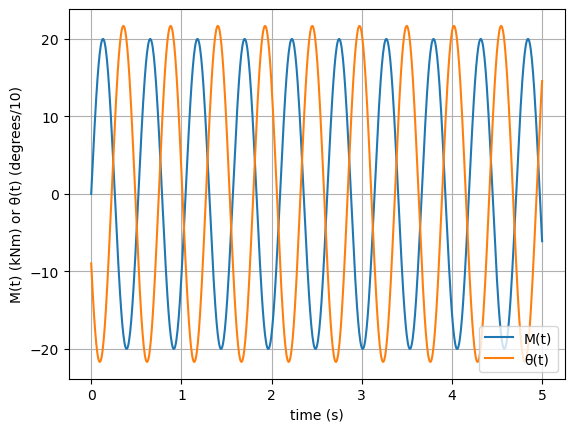

In [11]:
figure(1)

plot(tt,M/1000,label = 'M(t)')
plot(tt,10*rad2deg(θ),label = 'θ(t)')
xlabel('time (s)')
ylabel('M(t) (kNm) or θ(t) (degrees/10)')
grid(True)
legend(loc = 'lower right')
show()